### **Project- Retail Sales Analysis**

## Section 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

# Better numeric formatting
pd.options.display.float_format = '{:,.2f}'.format

# Section 2 — Load Datasets

In [4]:
from google.colab import files

uploaded = files.upload()


Saving shipments.csv to shipments.csv
Saving stores.csv to stores.csv
Saving products.csv to products.csv
Saving payments.csv to payments.csv
Saving orders.csv to orders.csv
Saving order_items.csv to order_items.csv
Saving customers.csv to customers (1).csv
Saving categories.csv to categories.csv


In [6]:
customers = pd.read_csv("customers.csv")
stores = pd.read_csv("stores.csv")
categories = pd.read_csv("categories.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
shipments = pd.read_csv("shipments.csv")

In [7]:
print(customers.shape)
print(stores.shape)
print(categories.shape)
print(products.shape)
print(orders.shape)
print(order_items.shape)
print(payments.shape)
print(shipments.shape)

(50000, 3)
(100, 2)
(30, 2)
(10000, 4)
(300000, 5)
(600000, 5)
(300000, 3)
(300000, 3)


## Section 3: Dataset Overview

In [9]:
datasets = {
    "Customers": customers,
    "Stores": stores,
    "Categories": categories,
    "Products": products,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Shipments": shipments
}

In [10]:
#Display the First 5 Rows
for name, df in datasets.items():
    print("=" * 80)
    print(f"{name.upper()} DATASET")
    print("=" * 80)
    display(df.head())

CUSTOMERS DATASET


,customer_id,city,signup_date
0,1,Mumbai,2021-02-16
1,2,Bangalore,2019-06-22
2,3,Pune,2022-01-25
3,4,Mumbai,2023-06-14
4,5,Delhi,2023-06-24


STORES DATASET


,store_id,city
0,1,Pune
1,2,Pune
2,3,Delhi
3,4,Mumbai
4,5,Mumbai


CATEGORIES DATASET


...

,order_item_id,order_id,product_id,qty,price
0,1,145042,472,3,176
1,2,110932,1666,2,1034
2,3,269799,8616,4,2290
3,4,298741,9909,3,1555
4,5,105218,1179,3,936


PAYMENTS DATASET


,payment_id,order_id,amount
0,1,1,1462
1,2,2,2272
2,3,3,1342
3,4,4,1906
4,5,5,7185


SHIPMENTS DATASET


,shipment_id,order_id,status
0,1,1,delivered
1,2,2,shipped
2,3,3,late
3,4,4,late
4,5,5,late


In [11]:
#Dataset Information
for name, df in datasets.items():
    print("=" * 80)
    print(f"{name.upper()} INFO")
    print("=" * 80)
    df.info()
    print("\n")

CUSTOMERS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  50000 non-null  int64 
 1   city         50000 non-null  object
 2   signup_date  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


STORES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   store_id  100 non-null    int64 
 1   city      100 non-null    object
dtypes: int64(1), object(1)
memory usage: 1.7+ KB


CATEGORIES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category_id    30 non-null     int64 
 1   category_name  30 non-null     object
dtypes: int

In [12]:
#Statistical Summary
for name, df in datasets.items():
    print("=" * 80)
    print(f"{name.upper()} SUMMARY")
    print("=" * 80)
    display(df.describe(include='all'))

CUSTOMERS SUMMARY


,customer_id,city,signup_date
count,"50,000.00",50000,50000
unique,NaN,4,1827
top,NaN,Mumbai,2022-03-02
freq,NaN,12656,45
mean,"25,000.50",NaN,NaN
std,"14,433.90",NaN,NaN
min,1.00,NaN,NaN
25%,"12,500.75",NaN,NaN
50%,"25,000.50",NaN,NaN
75%,"37,500.25",NaN,NaN


STORES SUMMARY


,store_id,city
count,100.00,100
unique,NaN,4
top,NaN,Mumbai
freq,NaN,31
mean,50.50,NaN
std,29.01,NaN
min,1.00,NaN
25%,25.75,NaN
50%,50.50,NaN
75%,75.25,NaN


CATEGORIES SUMMARY


...

,order_item_id,order_id,product_id,qty,price
count,"600,000.00","600,000.00","600,000.00","600,000.00","600,000.00"
mean,"300,000.50","149,916.35","5,006.51",2.50,"2,550.25"
std,"173,205.23","86,589.96","2,887.87",1.12,"1,414.78"
min,1.00,1.00,1.00,1.00,100.00
25%,"150,000.75","74,985.00","2,507.00",2.00,"1,324.00"
50%,"300,000.50","149,903.00","5,011.00",3.00,"2,551.00"
75%,"450,000.25","224,968.00","7,501.00",3.00,"3,776.00"
max,"600,000.00","300,000.00","10,000.00",4.00,"4,999.00"


PAYMENTS SUMMARY


,payment_id,order_id,amount
count,"300,000.00","300,000.00","300,000.00"
mean,"150,000.50","150,000.50","10,060.27"
std,"86,602.68","86,602.68","5,746.15"
min,1.00,1.00,100.00
25%,"75,000.75","75,000.75","5,085.00"
50%,"150,000.50","150,000.50","10,068.00"
75%,"225,000.25","225,000.25","15,035.25"
max,"300,000.00","300,000.00","19,999.00"


SHIPMENTS SUMMARY


,shipment_id,order_id,status
count,"300,000.00","300,000.00",300000
unique,NaN,NaN,3
top,NaN,NaN,shipped
freq,NaN,NaN,100283
mean,"150,000.50","150,000.50",NaN
std,"86,602.68","86,602.68",NaN
min,1.00,1.00,NaN
25%,"75,000.75","75,000.75",NaN
50%,"150,000.50","150,000.50",NaN
75%,"225,000.25","225,000.25",NaN


In [13]:
#Check Data Types
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.dtypes.to_frame(name="Data Type"))


Customers


,Data Type
customer_id,int64
city,object
signup_date,object



Stores


,Data Type
store_id,int64
city,object



Categories


...

,Data Type
order_item_id,int64
order_id,int64
product_id,int64
qty,int64
price,int64



Payments


,Data Type
payment_id,int64
order_id,int64
amount,int64



Shipments


,Data Type
shipment_id,int64
order_id,int64
status,object


In [14]:
#Display Column Names
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Customers
['customer_id', 'city', 'signup_date']

Stores
['store_id', 'city']

Categories
['category_id', 'category_name']

Products
['product_id', 'category_id', 'supplier_id', 'price']

Orders
['order_id', 'customer_id', 'store_id', 'order_date', 'promotion_id']

Order Items
['order_item_id', 'order_id', 'product_id', 'qty', 'price']

Payments
['payment_id', 'order_id', 'amount']

Shipments
['shipment_id', 'order_id', 'status']


#Section 4: Data Quality Assessment

In [15]:
#Missing Values
missing_values = {}

for name, df in datasets.items():
    missing_values[name] = df.isnull().sum()

for name, missing in missing_values.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    print(missing)
    print()

Customers
customer_id    0
city           0
signup_date    0
dtype: int64

Stores
store_id    0
city        0
dtype: int64

Categories
category_id      0
category_name    0
dtype: int64

Products
product_id     0
category_id    0
supplier_id    0
price          0
dtype: int64

Orders
order_id        0
customer_id     0
store_id        0
order_date      0
promotion_id    0
dtype: int64

Order Items
order_item_id    0
order_id         0
product_id       0
qty              0
price            0
dtype: int64

Payments
payment_id    0
order_id      0
amount        0
dtype: int64

Shipments
shipment_id    0
order_id       0
status         0
dtype: int64



In [16]:
#Duplicate Rows
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Customers: 0 duplicate rows
Stores: 0 duplicate rows
Categories: 0 duplicate rows
Products: 0 duplicate rows
Orders: 0 duplicate rows
Order Items: 0 duplicate rows
Payments: 0 duplicate rows
Shipments: 0 duplicate rows


In [17]:
#Dataset Memory Usage
for name, df in datasets.items():
    memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"{name}: {memory:.2f} MB")

Customers: 5.82 MB
Stores: 0.01 MB
Categories: 0.00 MB
Products: 0.31 MB
Orders: 26.04 MB
Order Items: 22.89 MB
Payments: 6.87 MB
Shipments: 20.50 MB


##Section 5: Data Integration (Merge Datasets)



In [18]:
# Merge Datasets
# Merge Orders with Customers
master_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

# Merge Stores
master_df = master_df.merge(
    stores,
    on="store_id",
    how="left",
    suffixes=("", "_store")
)

# Merge Payments
master_df = master_df.merge(
    payments,
    on="order_id",
    how="left"
)

# Merge Order Items
master_df = master_df.merge(
    order_items,
    on="order_id",
    how="left",
    suffixes=("", "_item")
)

# Merge Products
master_df = master_df.merge(
    products,
    on="product_id",
    how="left"
)

# Merge Categories
master_df = master_df.merge(
    categories,
    on="category_id",
    how="left"
)

# Merge Shipments
master_df = master_df.merge(
    shipments,
    on="order_id",
    how="left",
    suffixes=("", "_shipment")
)

In [35]:
master_df.isnull().sum().sort_values(ascending=False)

,0
price_y,40767
category_name,40767
product_id,40767
order_item_id,40767
supplier_id,40767
category_id,40767
price_x,40767
qty,40767
order_date,0
store_id,0


In [38]:
analysis_df = master_df.dropna(
    subset=["order_item_id"]
).copy()

analysis_df.shape


(600000, 20)

In [39]:
analysis_df.isnull().sum()

,0
order_id,0
customer_id,0
store_id,0
order_date,0
promotion_id,0
city,0
signup_date,0
city_store,0
payment_id,0
amount,0


##Section 6: Exploratory Data Analysis (EDA)

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

# Create folder for saving charts
os.makedirs("EDA_Charts", exist_ok=True)

# Matplotlib Settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11

# Currency Formatter
currency = FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')

#create analysis dataframes

In [75]:
#order-level data
order_df = (
    orders
    .merge(payments, on='order_id')
    .merge(customers, on='customer_id')
    .merge(stores, on='store_id')
)

order_df.head()

,order_id,customer_id,store_id,order_date,promotion_id,payment_id,amount,city_x,signup_date,city_y
0,1,45308,33,2021-08-26,24,1,1462,Pune,2019-06-24,Pune
1,2,10070,81,2022-03-19,3,2,2272,Bangalore,2019-10-18,Delhi
2,3,43308,17,2021-01-21,25,3,1342,Delhi,2022-05-26,Delhi
3,4,47997,85,2021-01-16,48,4,1906,Pune,2022-11-03,Mumbai
4,5,36546,81,2022-09-14,33,5,7185,Delhi,2023-06-06,Delhi


In [76]:
order_df = order_df.rename(columns={
    'city_x': 'customer_city',
    'city_y': 'store_city'
})

In [77]:
#product-level data

product_df = (
    order_items
    .merge(
        products,
        on='product_id',
        how='left',
        suffixes=('_order', '_product')
    )
    .merge(
        categories,
        on='category_id',
        how='left'
    )
)

product_df['revenue'] = (
    product_df['qty'] *
    product_df['price_order']
)

product_df.head()

,order_item_id,order_id,product_id,qty,price_order,category_id,supplier_id,price_product,category_name,revenue
0,1,145042,472,3,176,13,189,4048,Cat_13,528
1,2,110932,1666,2,1034,2,127,4957,Cat_2,2068
2,3,269799,8616,4,2290,18,27,2728,Cat_18,9160
3,4,298741,9909,3,1555,19,126,353,Cat_19,4665
4,5,105218,1179,3,936,9,84,4417,Cat_9,2808


In [78]:
#shipment data
shipment_df = (
    shipments
    .merge(orders, on='order_id')
)

shipment_df.head()

,shipment_id,order_id,status,customer_id,store_id,order_date,promotion_id
0,1,1,delivered,45308,33,2021-08-26,24
1,2,2,shipped,10070,81,2022-03-19,3
2,3,3,late,43308,17,2021-01-21,25
3,4,4,late,47997,85,2021-01-16,48
4,5,5,late,36546,81,2022-09-14,33


In [79]:
# ==============================
# Key Performance Indicators
# ==============================
kpis = {

    "Total Revenue":
    order_df['amount'].sum(),

    "Total Orders":
    order_df['order_id'].nunique(),

    "Total Customers":
    customers['customer_id'].nunique(),

    "Total Products":
    products['product_id'].nunique(),

    "Total Stores":
    stores['store_id'].nunique(),

    "Total Categories":
    categories['category_id'].nunique(),

    "Average Order Value":
    order_df['amount'].mean()

}

kpi_df = pd.DataFrame(
    kpis.items(),
    columns=['Metric','Value']
)

kpi_df


,Metric,Value
0,Total Revenue,"3,018,080,810.00"
1,Total Orders,"300,000.00"
2,Total Customers,"50,000.00"
3,Total Products,"10,000.00"
4,Total Stores,100.00
5,Total Categories,30.00
6,Average Order Value,"10,060.27"


In [80]:
analysis_df['order_date'] = pd.to_datetime(
    analysis_df['order_date']
)

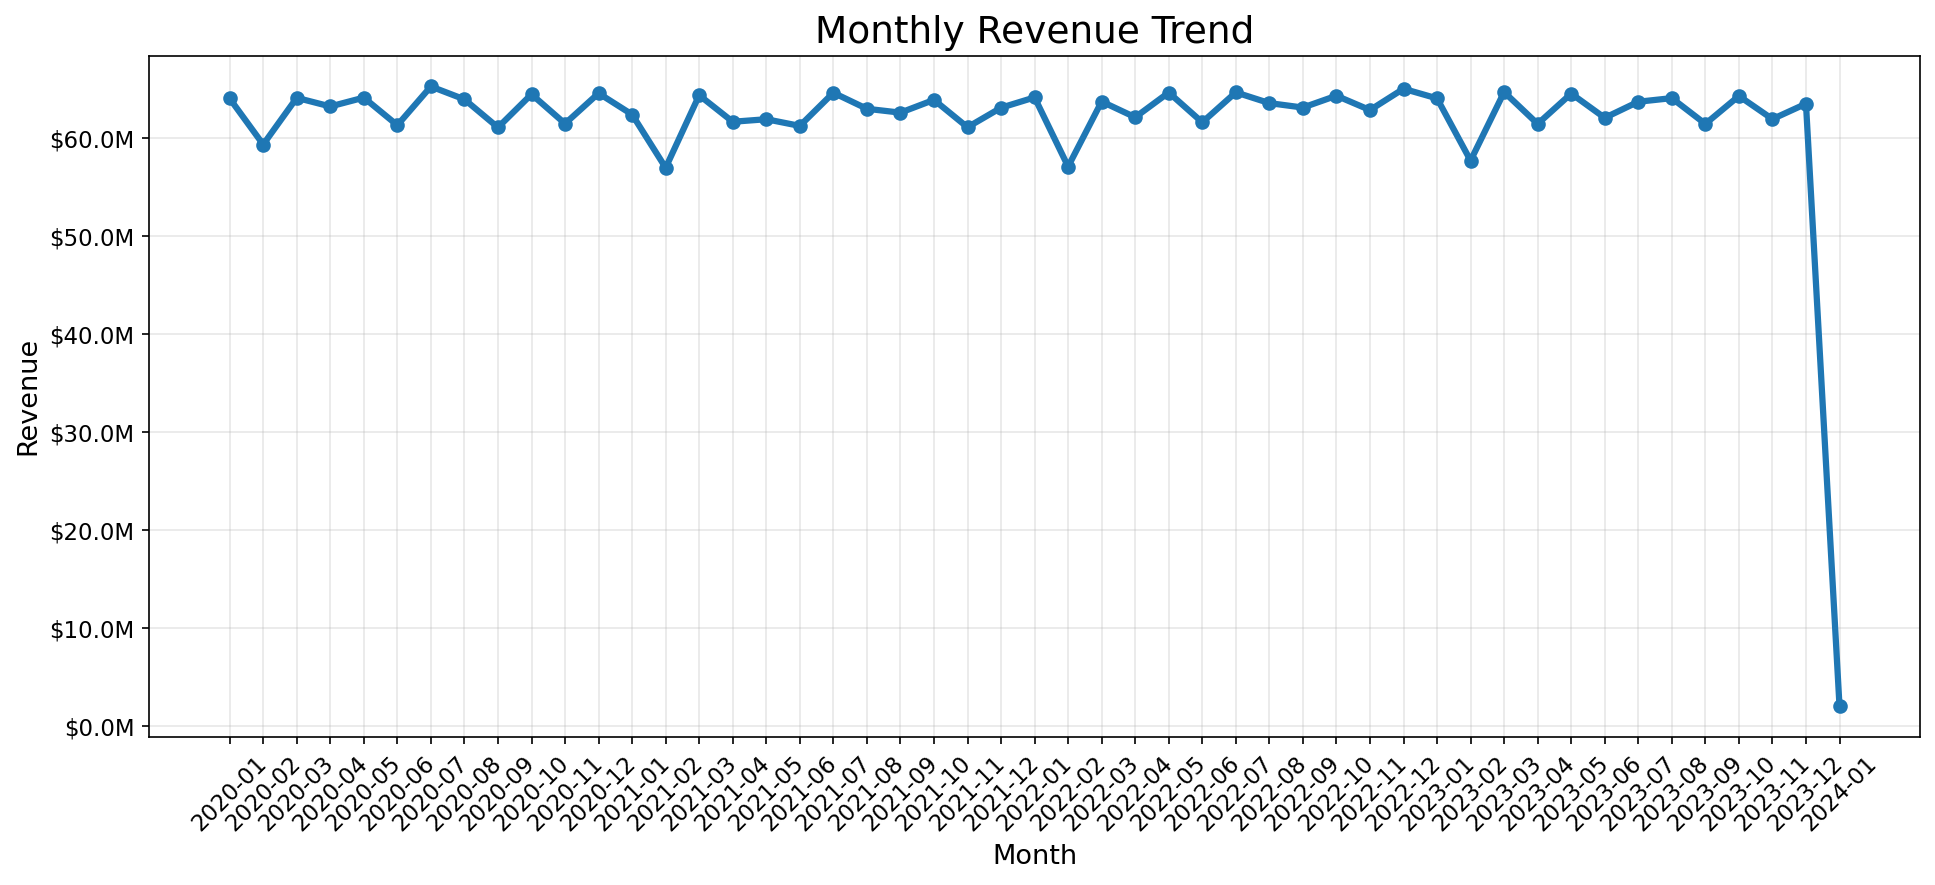

In [98]:
# ==============================
# Monthly Revenue Trend
# ==============================

order_df['order_date'] = pd.to_datetime(order_df['order_date'])

monthly_revenue = (
    order_df
    .groupby(
        order_df['order_date'].dt.to_period('M')
    )['amount']
    .sum()
    .reset_index()
)

monthly_revenue['order_date'] = (
    monthly_revenue['order_date']
    .astype(str)
)

plt.figure(figsize=(13,6))

plt.plot(
    monthly_revenue['order_date'],
    monthly_revenue['amount'],
    linewidth=3,
    marker='o'
)

ax = plt.gca()
ax.yaxis.set_major_formatter(currency)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "EDA_Charts/01_Monthly_Revenue.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

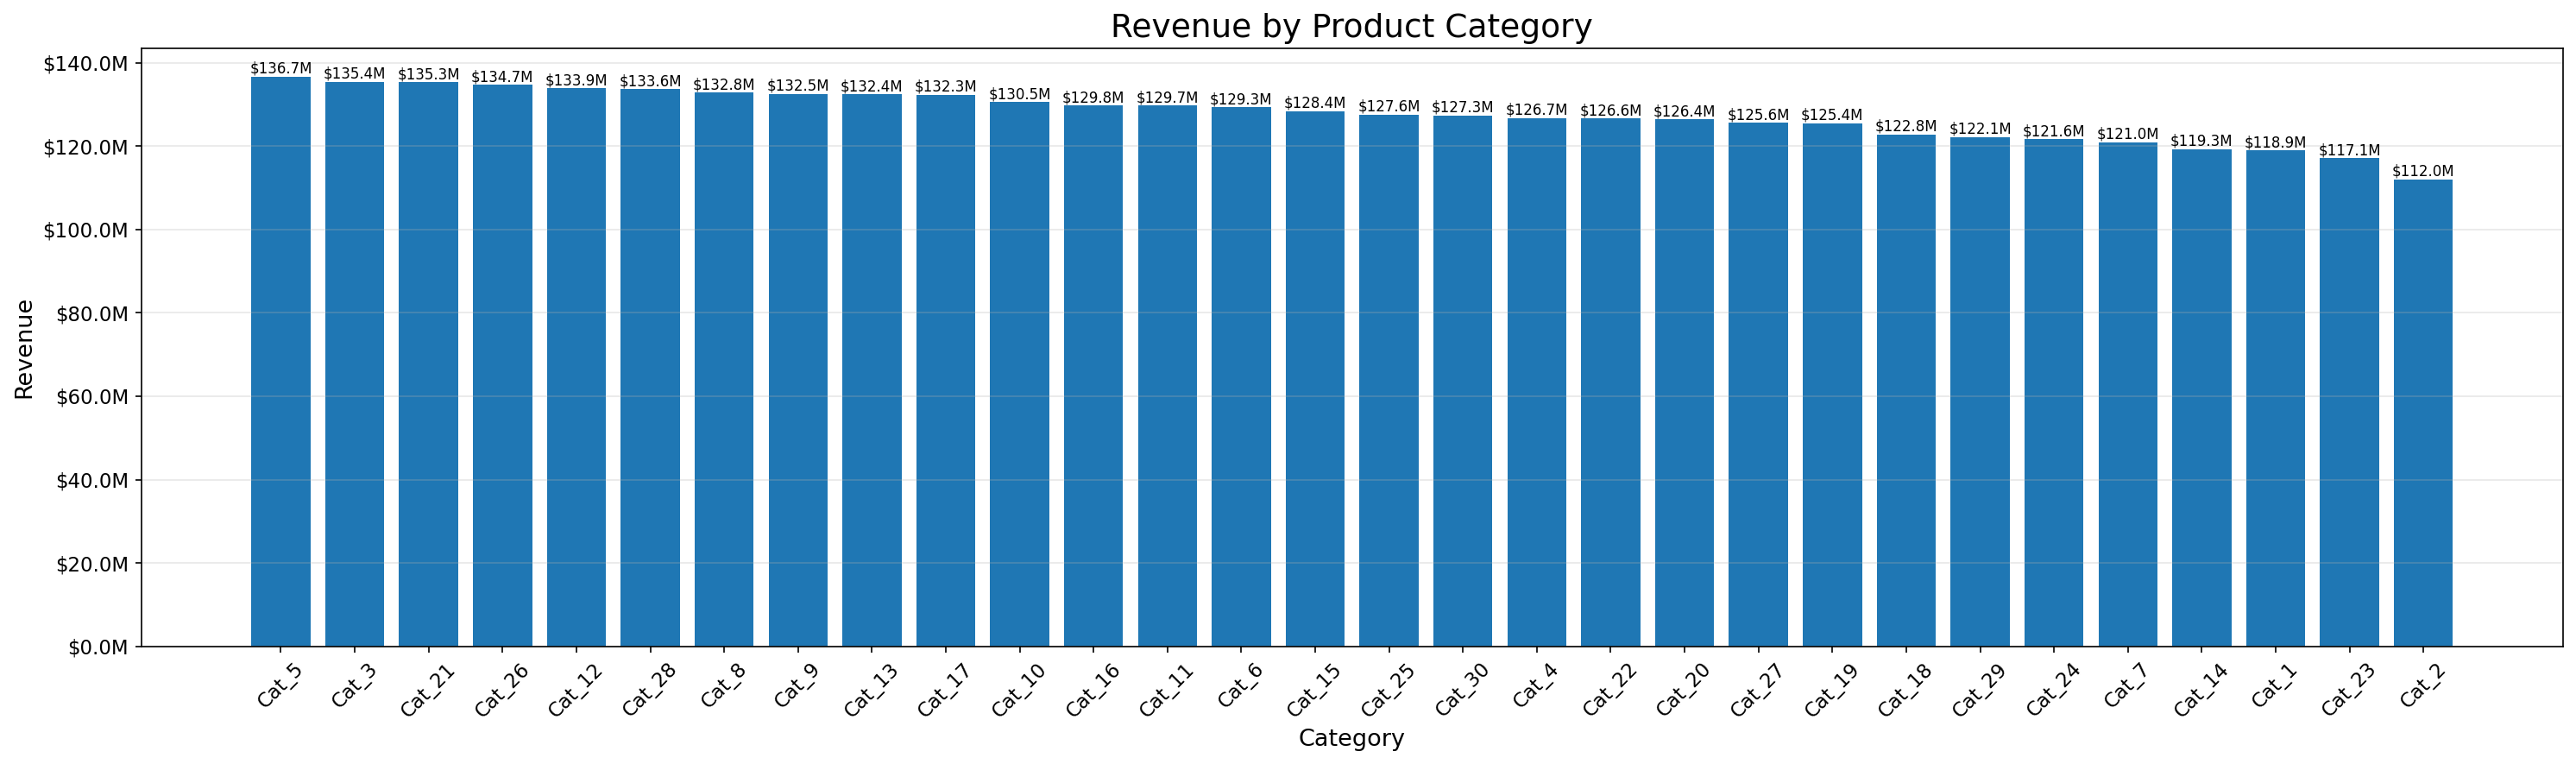

In [99]:
#revenue by product category
category_revenue = (
    product_df
    .groupby("category_name", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

plt.figure(figsize=(20,6))

bars = plt.bar(
    category_revenue["category_name"],
    category_revenue["revenue"]
)

ax = plt.gca()
ax.yaxis.set_major_formatter(currency)

plt.title("Revenue by Product Category", fontsize=18)

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"${height/1e6:.1f}M",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "EDA_Charts/02_Revenue_by_Category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

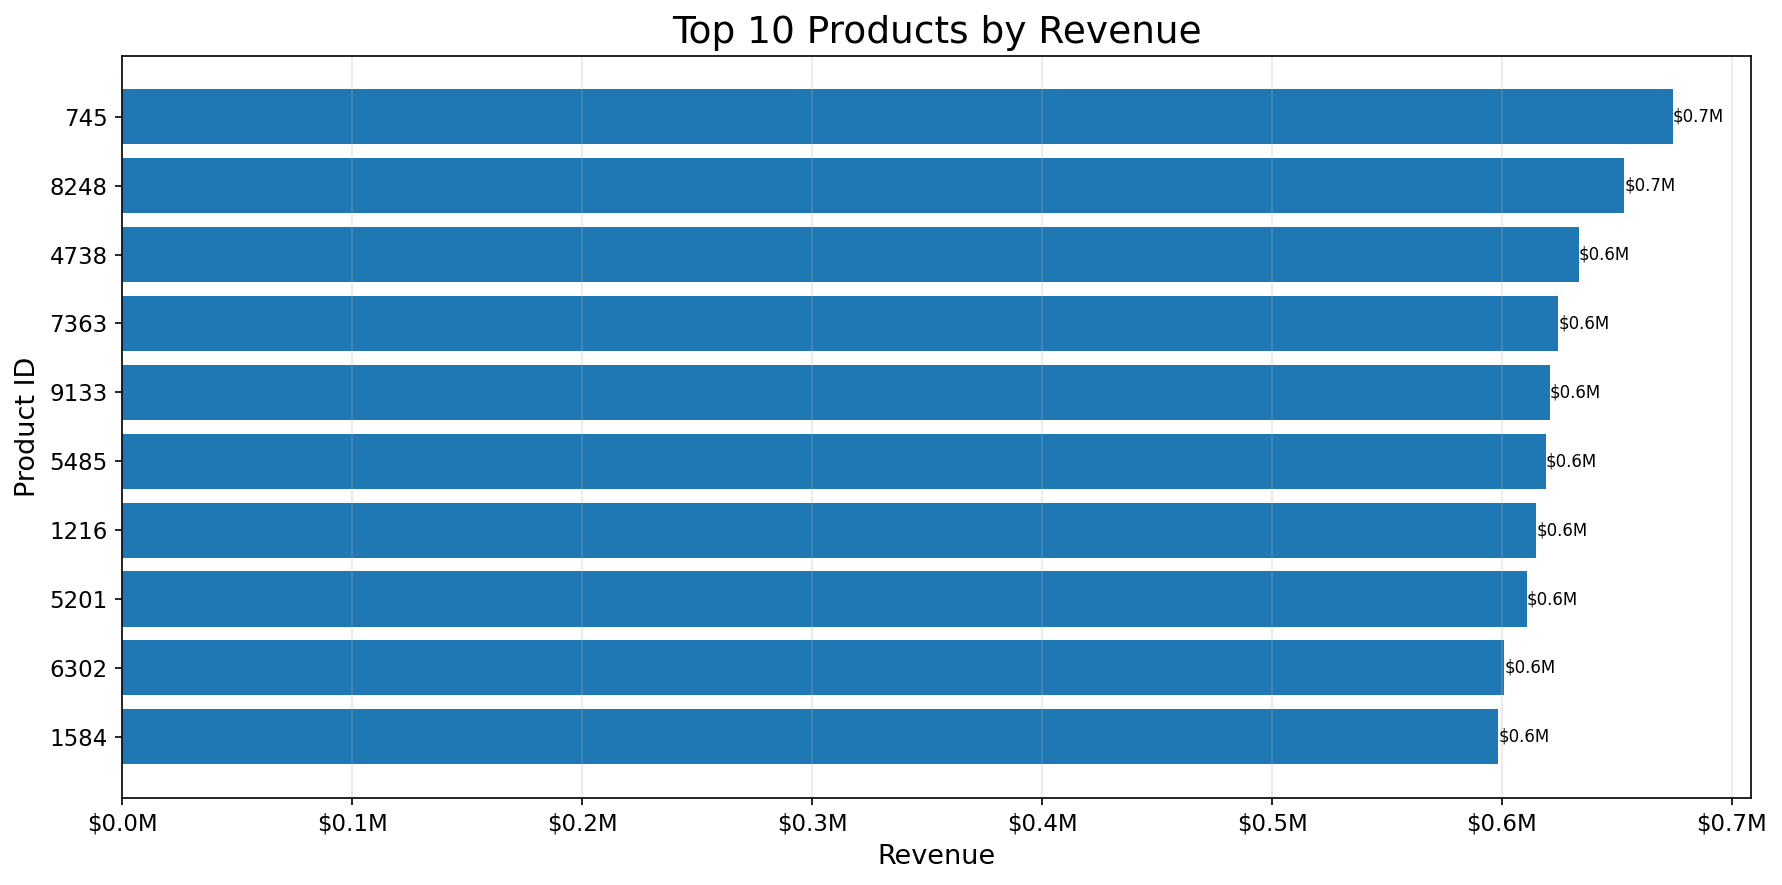

In [100]:
#top 10 products by revenue
top_products = (
    product_df
    .groupby("product_id", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_products["product_id"].astype(str),
    top_products["revenue"]
)

ax = plt.gca()
ax.xaxis.set_major_formatter(currency)

plt.title("Top 10 Products by Revenue")

plt.xlabel("Revenue")

plt.ylabel("Product ID")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"${width/1e6:.1f}M",
        va='center',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "EDA_Charts/03_Top_Products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

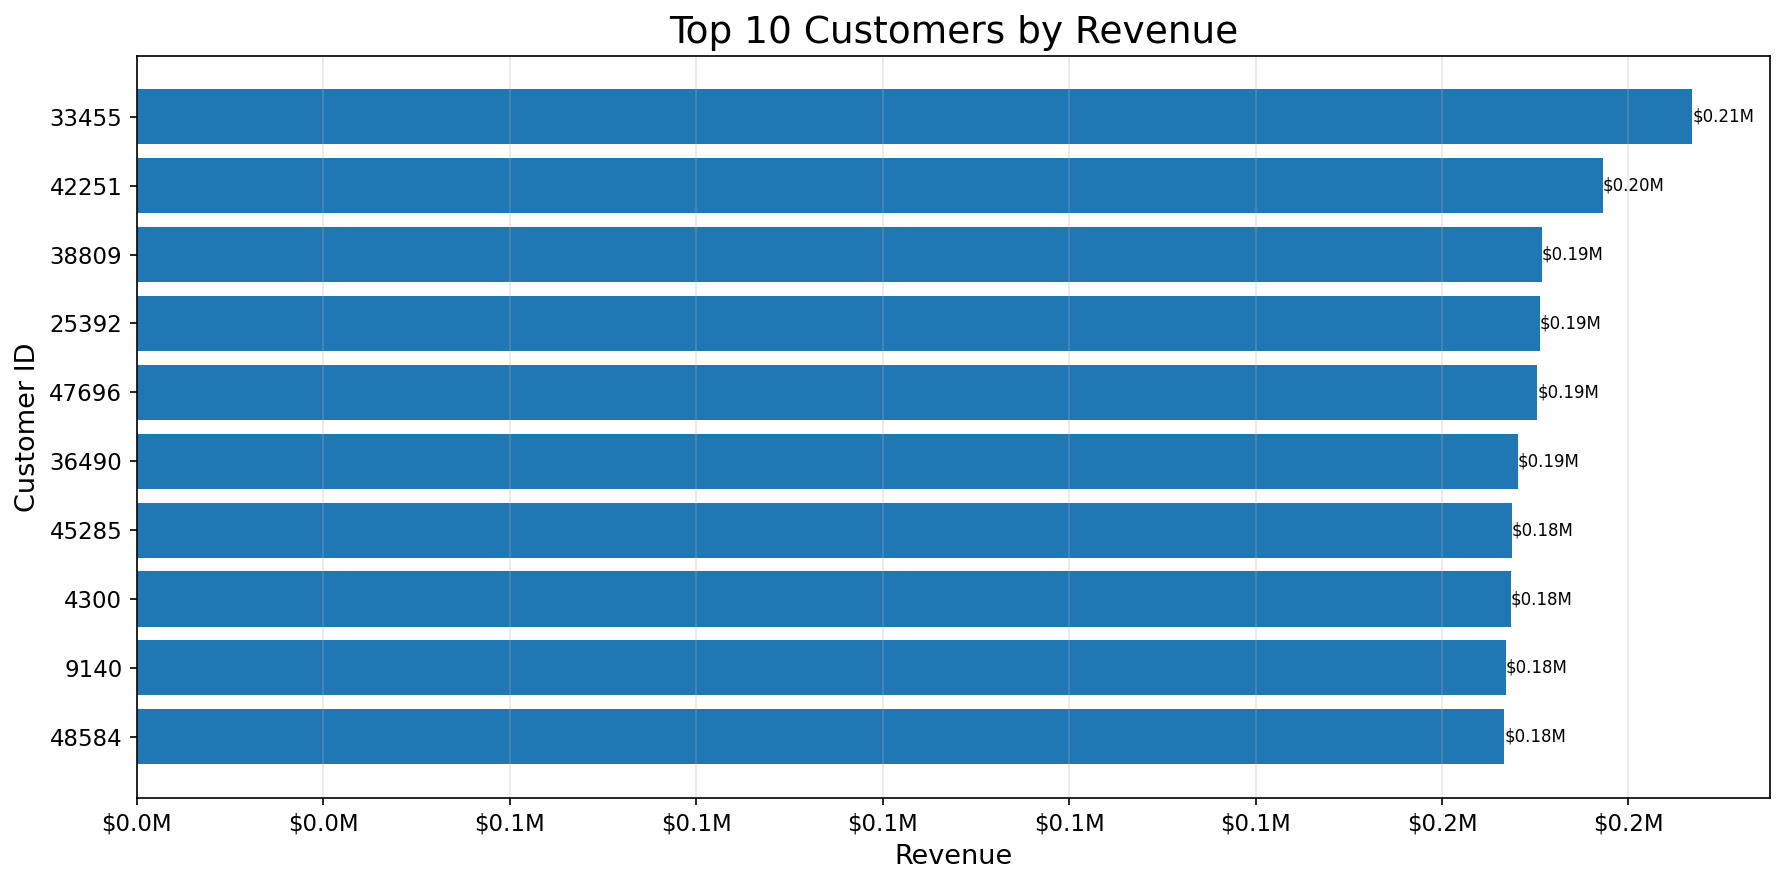

In [101]:
#top 10 customers by revenue
customer_revenue = (
    order_df
    .groupby('customer_id', as_index=False)['amount']
    .sum()
    .sort_values('amount', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    customer_revenue['customer_id'].astype(str),
    customer_revenue['amount']
)

ax = plt.gca()
ax.xaxis.set_major_formatter(currency)

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Revenue")

plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"${width/1e6:.2f}M",
        va='center',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "EDA_Charts/04_Top_Customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

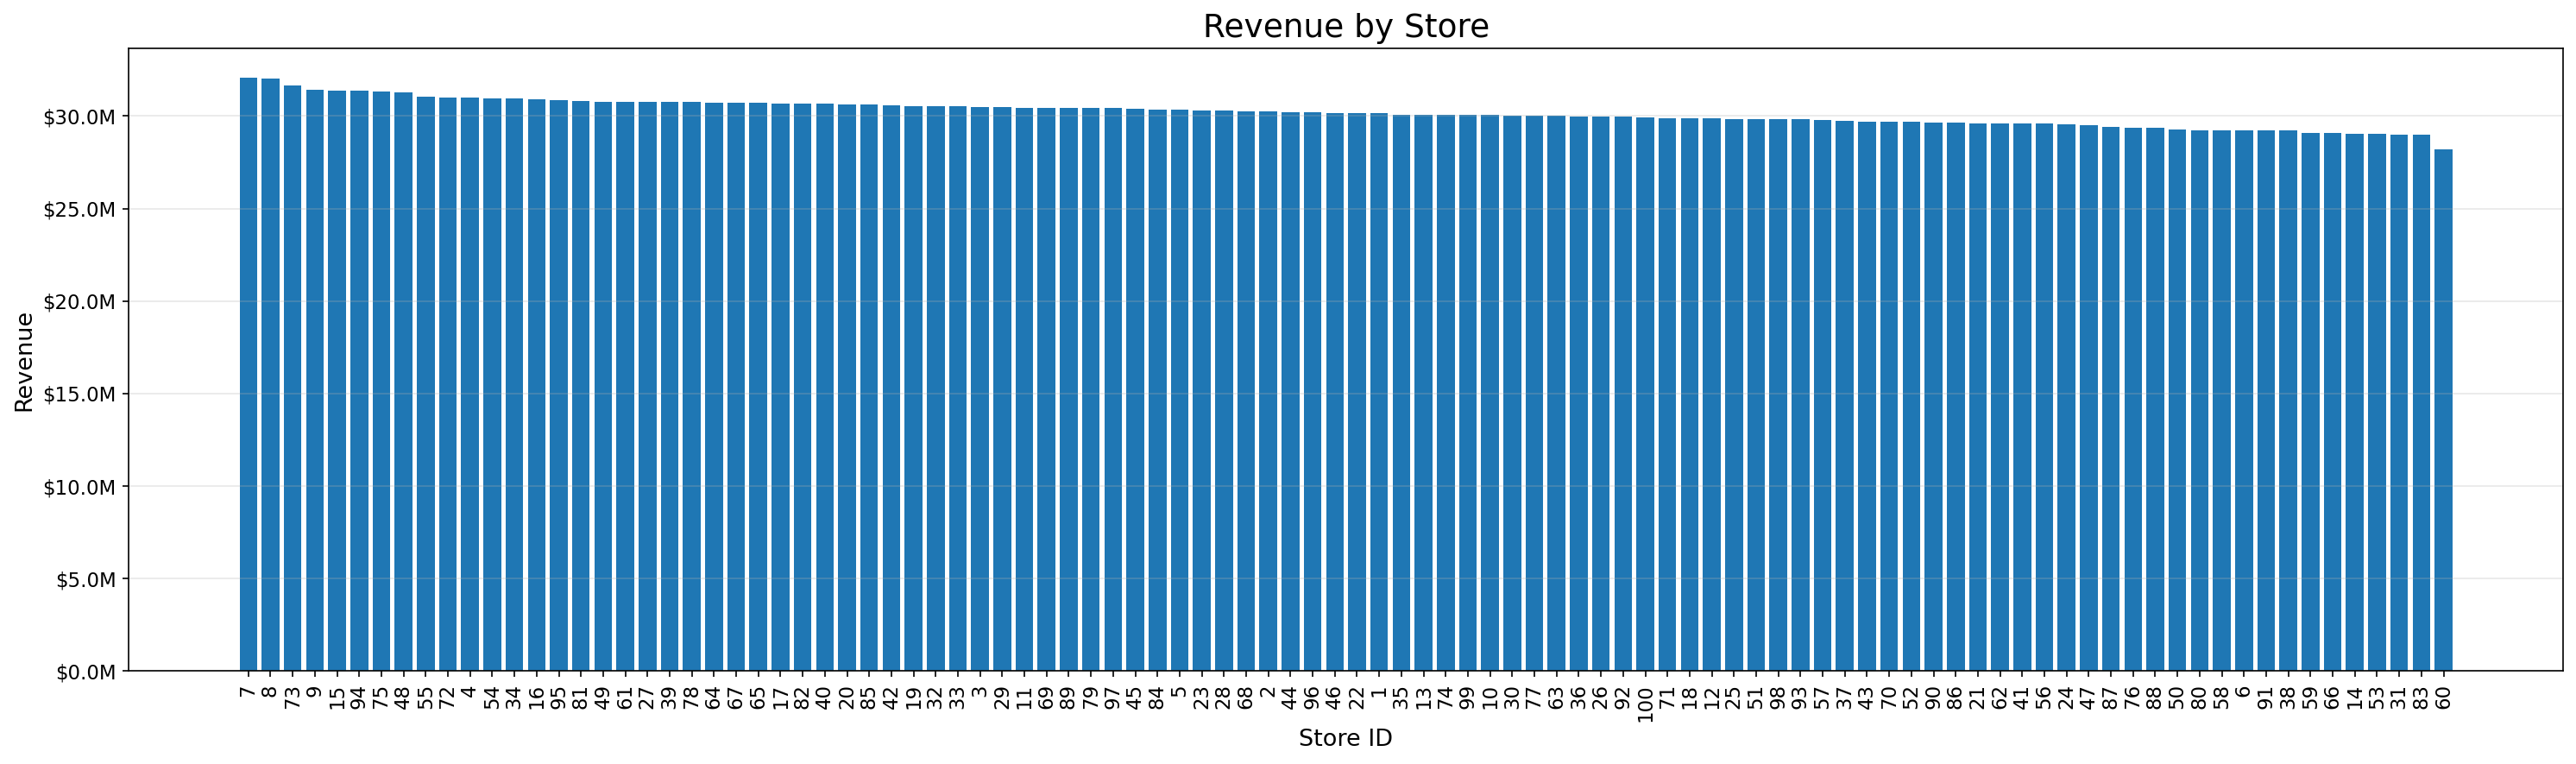

In [102]:
#revenue by store
store_revenue = (
    order_df
    .groupby('store_id', as_index=False)['amount']
    .sum()
    .sort_values('amount', ascending=False)
)

plt.figure(figsize=(20,6))

bars = plt.bar(
    store_revenue['store_id'].astype(str),
    store_revenue['amount']
)

ax = plt.gca()
ax.yaxis.set_major_formatter(currency)

plt.title("Revenue by Store")

plt.xlabel("Store ID")

plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "EDA_Charts/05_Revenue_by_Store.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

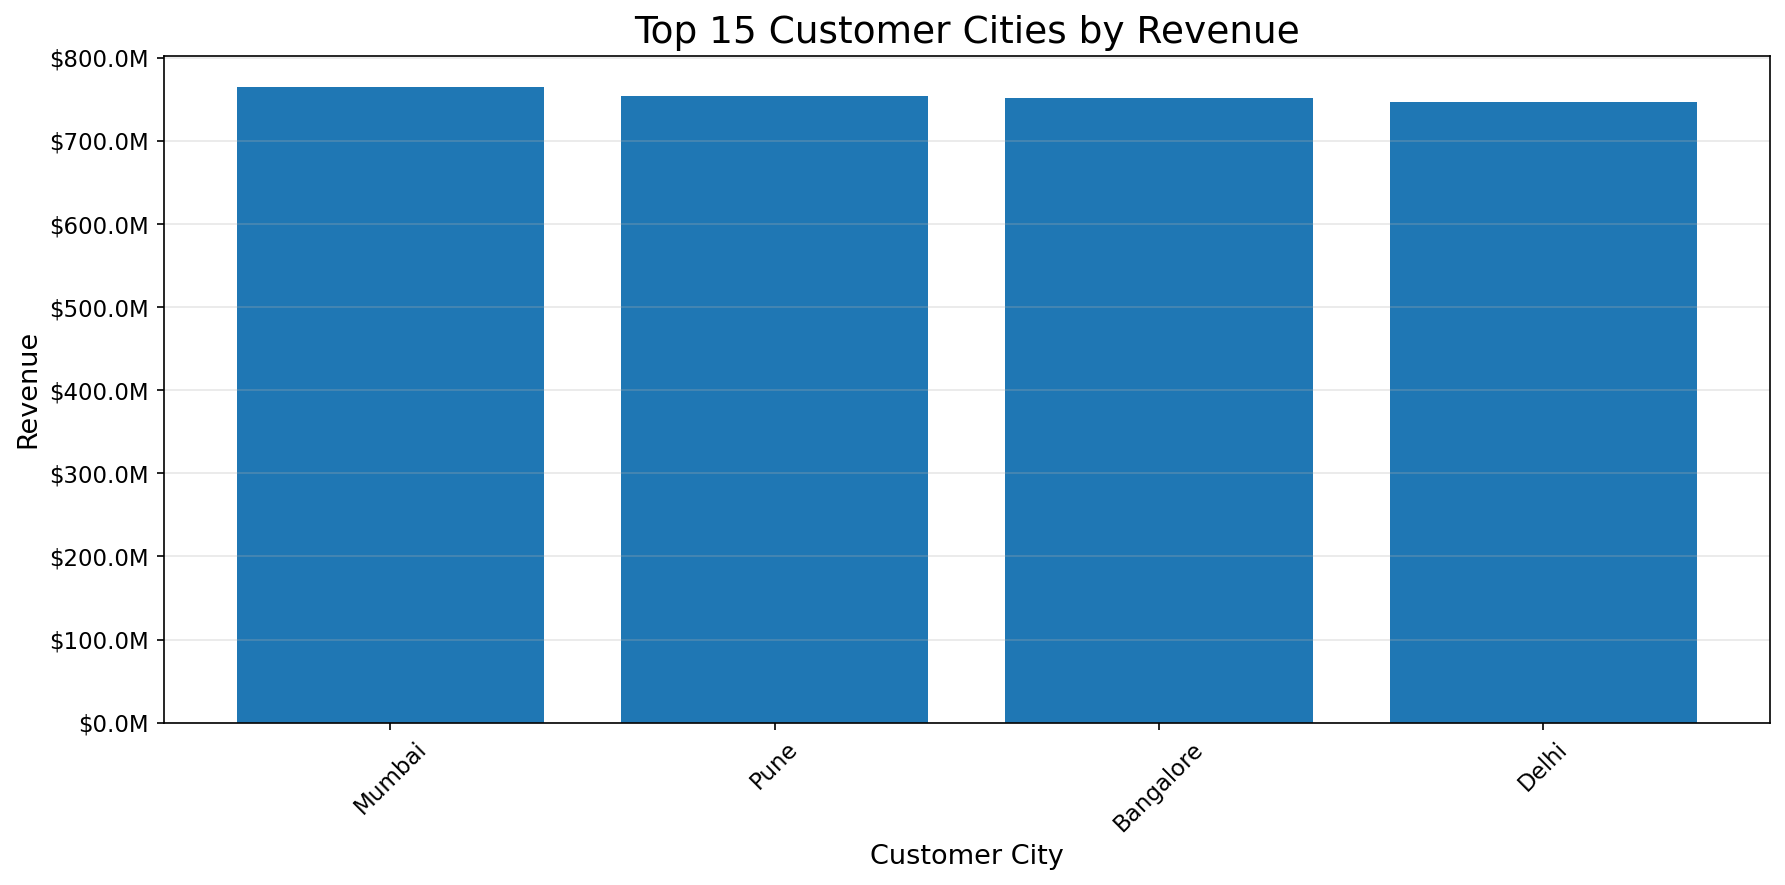

In [103]:
#revenue by customer city
city_revenue = (
    order_df
    .groupby('customer_city', as_index=False)['amount']
    .sum()
    .sort_values('amount', ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    city_revenue['customer_city'],
    city_revenue['amount']
)

ax = plt.gca()
ax.yaxis.set_major_formatter(currency)

plt.title("Top 15 Customer Cities by Revenue")

plt.xlabel("Customer City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "EDA_Charts/06_Revenue_by_Customer_City.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

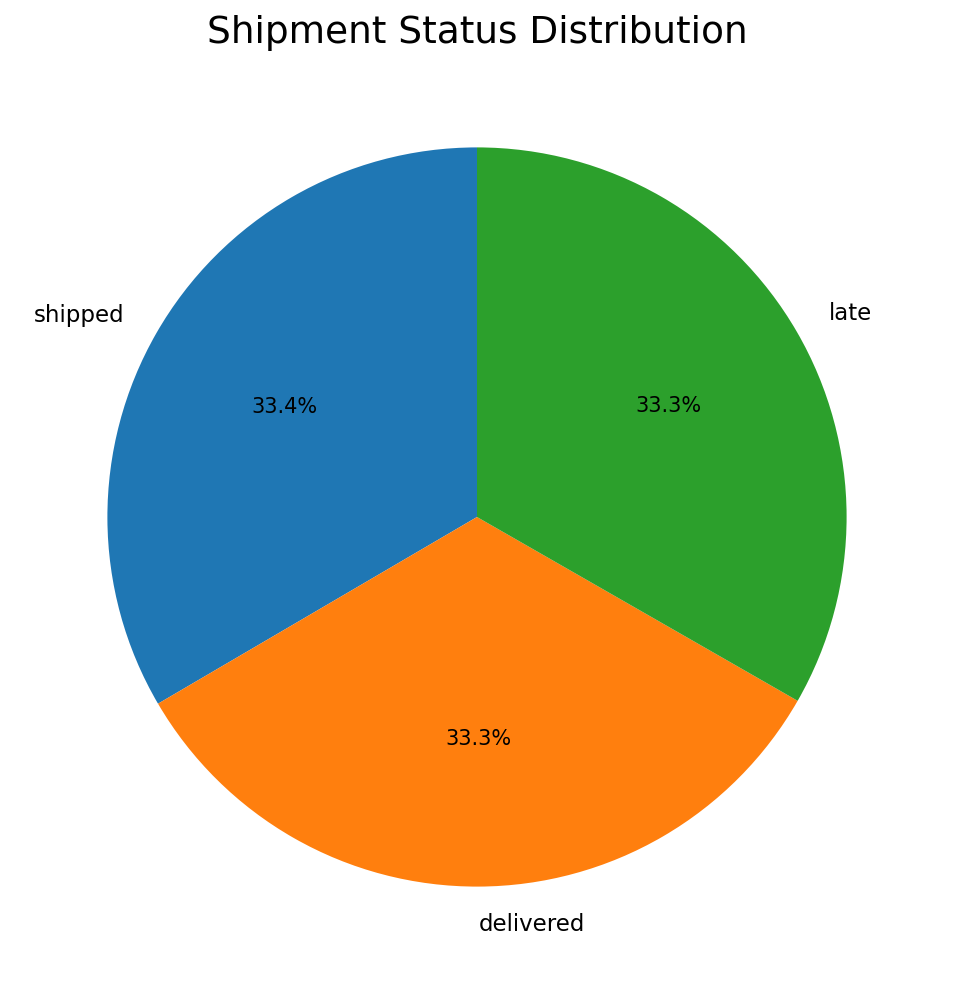

In [104]:
#shipment_status_distribution
shipment_status = (
    shipment_df['status']
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    shipment_status.values,
    labels=shipment_status.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Shipment Status Distribution")

plt.savefig(
    "EDA_Charts/07_Shipment_Status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

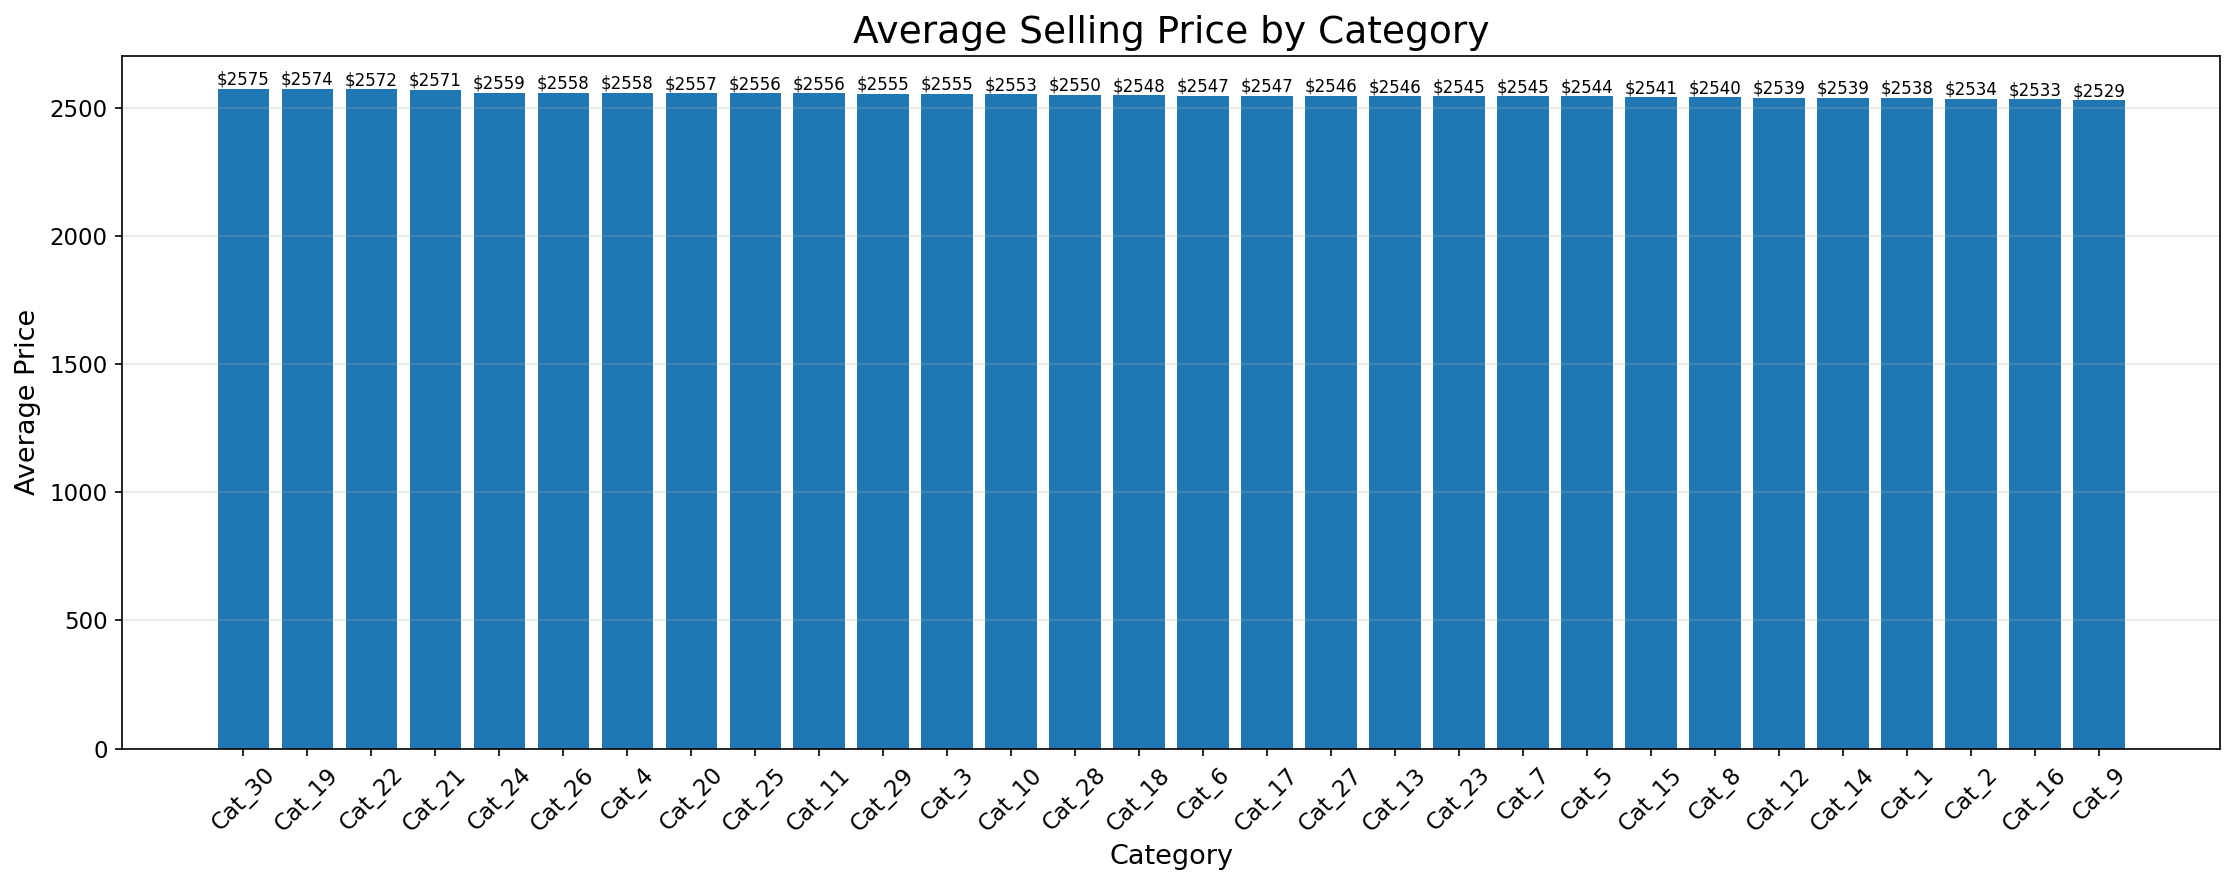

In [105]:
#average selling price by category
avg_price_category = (
    product_df
    .groupby('category_name', as_index=False)['price_order']
    .mean()
    .sort_values('price_order', ascending=False)
)

plt.figure(figsize=(15,6))

bars = plt.bar(
    avg_price_category['category_name'],
    avg_price_category['price_order']
)

plt.title("Average Selling Price by Category")

plt.xlabel("Category")

plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "EDA_Charts/08_Average_Price_by_Category.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

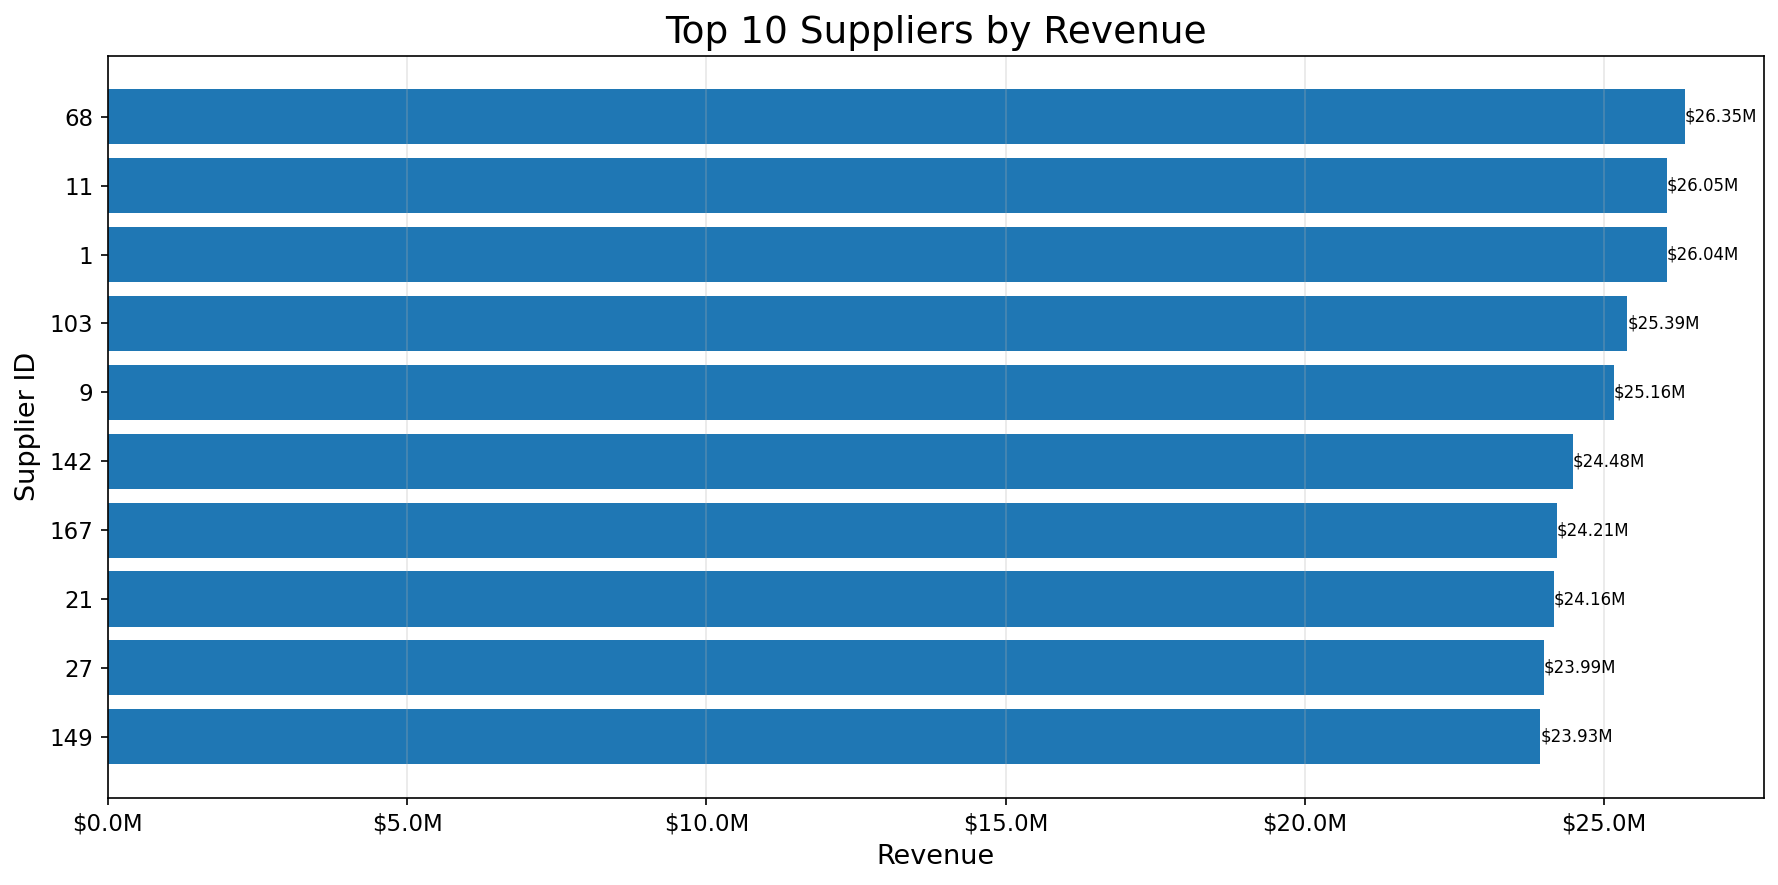

In [106]:
# ==========================================
# Top 10 Suppliers by Revenue
# ==========================================

supplier_revenue = (
    product_df
    .groupby('supplier_id', as_index=False)['revenue']
    .sum()
    .sort_values('revenue', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    supplier_revenue['supplier_id'].astype(str),
    supplier_revenue['revenue']
)

ax = plt.gca()
ax.xaxis.set_major_formatter(currency)

plt.title("Top 10 Suppliers by Revenue", fontsize=18)

plt.xlabel("Revenue")

plt.ylabel("Supplier ID")

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

# Value Labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width/1e6:.2f}M",
        va='center',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "EDA_Charts/09_Top_Suppliers_by_Revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

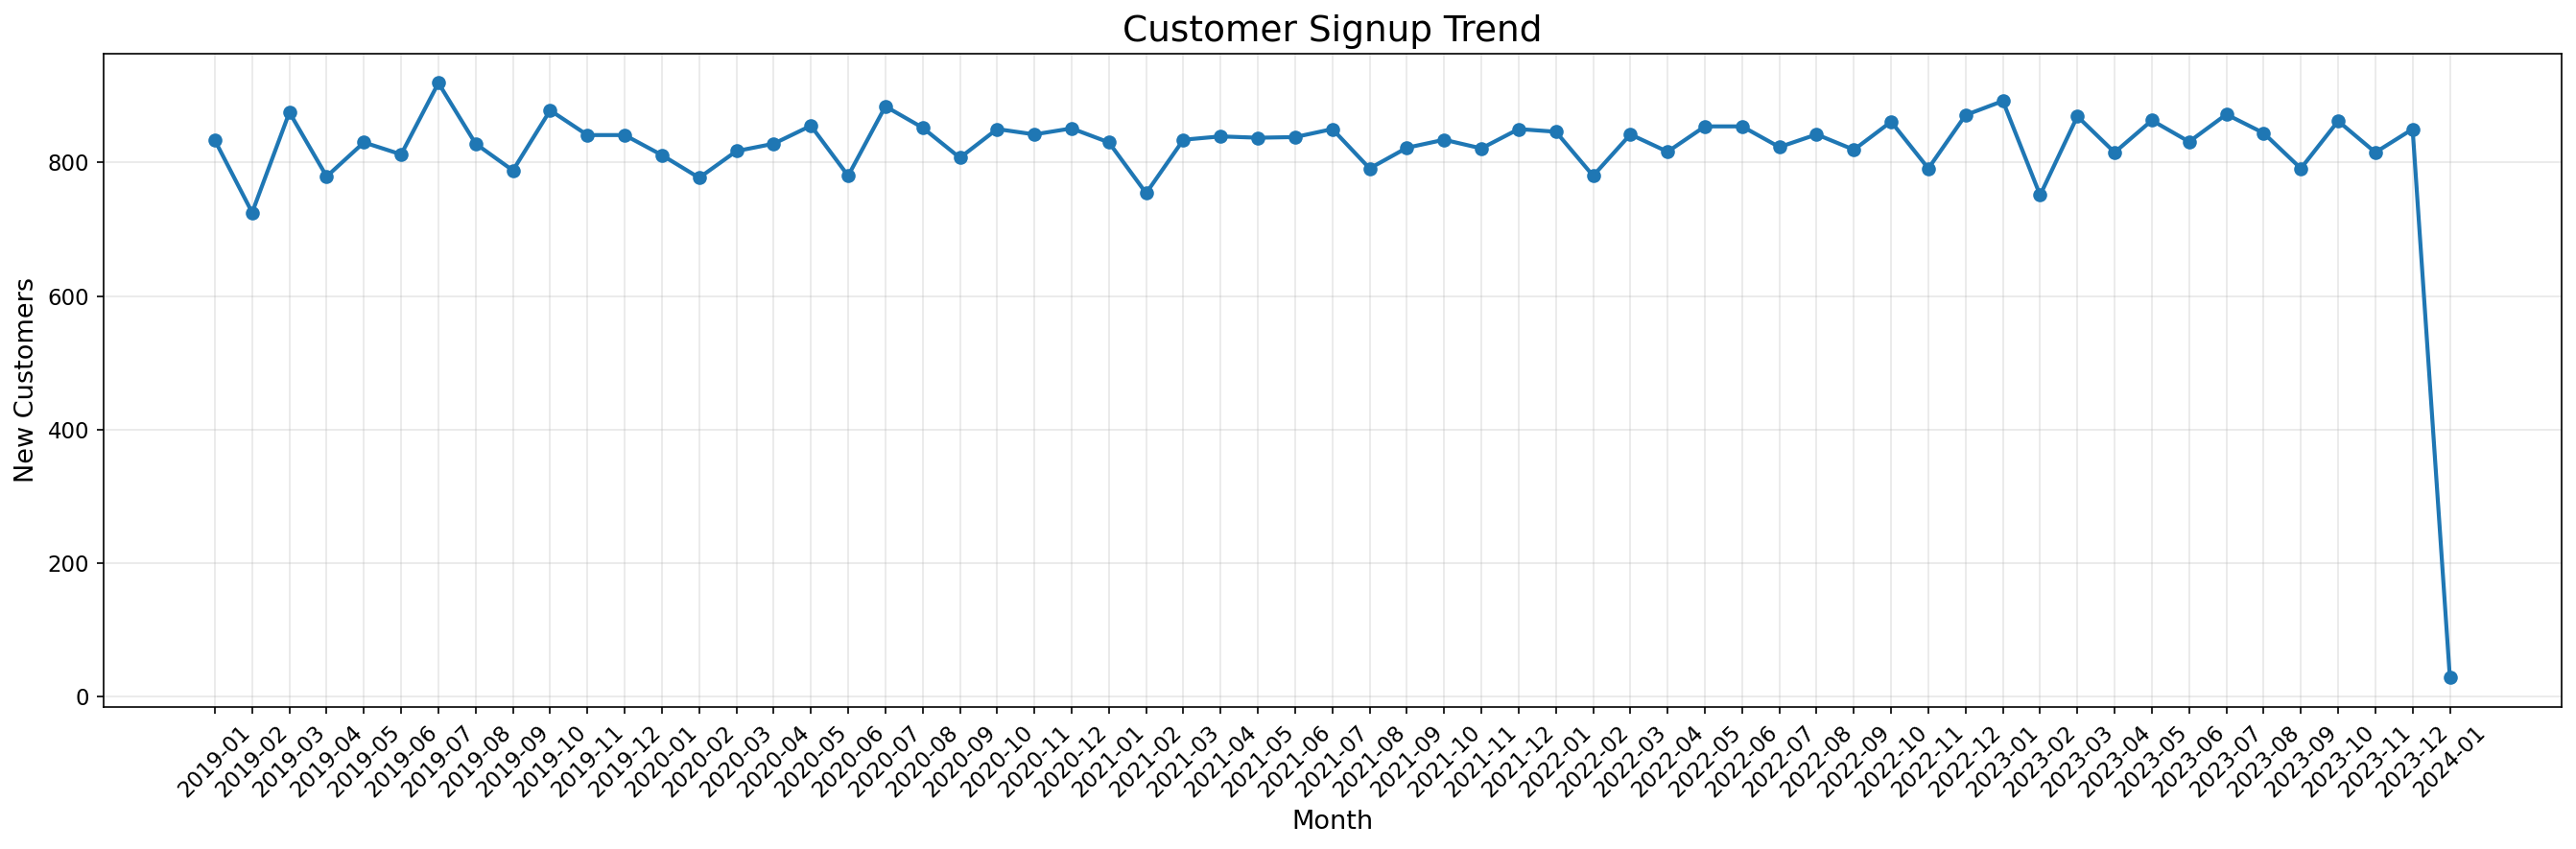

In [107]:
#customer signup trend
order_df['signup_date'] = pd.to_datetime(order_df['signup_date'])

signup_trend = (
    order_df
    .drop_duplicates('customer_id')
    .groupby(
        order_df
        .drop_duplicates('customer_id')['signup_date']
        .dt.to_period('M')
    )
    .size()
    .reset_index(name='customers')
)

signup_trend['signup_date'] = signup_trend['signup_date'].astype(str)

plt.figure(figsize=(18,6))

plt.plot(
    signup_trend['signup_date'],
    signup_trend['customers'],
    marker='o',
    linewidth=2
)

plt.title("Customer Signup Trend")

plt.xlabel("Month")

plt.ylabel("New Customers")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "EDA_Charts/10_Customer_Signups.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
!pip install pillow

In [109]:
from PIL import Image
import os

In [110]:
image_files = [
    "EDA_Charts/01_Monthly_Revenue.png",
    "EDA_Charts/02_Revenue_by_Category.png",
    "EDA_Charts/03_Top_Products.png",
    "EDA_Charts/04_Top_Customers.png",
    "EDA_Charts/05_Revenue_by_Store.png",
    "EDA_Charts/06_Revenue_by_Customer_City.png",
    "EDA_Charts/07_Shipment_Status.png",
    "EDA_Charts/08_Average_Price_by_Category.png",
    "EDA_Charts/09_Top_Suppliers_by_Revenue.png",
    "EDA_Charts/10_Customer_Signups.png"
]

In [111]:
images = []

for file in image_files:
    img = Image.open(file)

    if img.mode != "RGB":
        img = img.convert("RGB")

    images.append(img)

images[0].save(
    "Retail_Sales_EDA_Report.pdf",
    save_all=True,
    append_images=images[1:]
)

print("✅ PDF created successfully!")

✅ PDF created successfully!


In [112]:
from google.colab import files

files.download("Retail_Sales_EDA_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>